<a href="https://colab.research.google.com/github/jonasknoll57/Bachelorarbeit_Demand-AD/blob/main/V3_AD_Only_Mannheim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Zugangsberechtigung auf Drive

from google.colab import drive
drive.mount('/content/drive')

# Gezippte Daten werden entpackt und in hohes Verzeichnis gelegt

!cp "/content/drive/MyDrive/BA_Colab/data.zip" "/content/data.zip"

!unzip -q "/content/data.zip" -d "/content"

!rm "/content/data.zip"
!rm "/content/_MACOSX"


Mounted at /content/drive
rm: cannot remove '/content/_MACOSX': No such file or directory


In [6]:
"""
V3 — Anomaly Detection Pipeline für Mannheim (Bereinigte Version)
=================================================================
Fixes gegenüber V2:
  #1  Feature-Liste vereinheitlicht (kontextuelle Features werden tatsächlich genutzt)
  #2  Label-Qualität: Strengere Anomalie-Definition (MIN_HIST_MEAN=2, MIN_ABSOLUTE=5)
  #3  Scoring auf letzte Stunde(n) statt Mean über 24h-Fenster
  #4  Zero-Inflation: Inaktive Stunden optional filterbar + Top-N Station Modus
  #5  Demand-Only Scoring korrekt implementiert
  #6  Label-Konsistenz: Ein einziger Labeling-Schritt, keine Überschreibungen
  #7  Station-Kontext durch kontextuelle Features (z_score, residuals)
"""

# ══════════════════════════════════════════════════════════════
# 0 — Setup & Imports
# ══════════════════════════════════════════════════════════════

import os, glob, re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from shapely import wkb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve, auc, f1_score, roc_auc_score,
    classification_report, roc_curve
)
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


# ══════════════════════════════════════════════════════════════
# 1 — Pfade & Konfiguration
# ══════════════════════════════════════════════════════════════

# ── Pfade ──
DEMAND_BASE        = '/content/data/demand'
STATION_NAMES_PATH = '/content/data/station_names/station_names.parquet'
GEO_INFO_PATH      = '/content/data/geo_information/geo_information.parquet'
WEATHER_PATH       = '/content/data/weather/weather.parquet'
HOLIDAYS_PATH      = '/content/data/holidays/holidays.parquet'
VACATIONS_PATH     = '/content/data/vacations/vacations.parquet'

OUTPUT_PATH        = '/content/data/V3_AD_Mannheim.parquet'

# ── Konfiguration ──
CITY               = 'Mannheim'
NETWORK_NAME       = 'Mannheim'
WEATHER_STATION_ID = 292348
FEDERAL_STATE      = 'Baden-Württemberg'

# ── AD-Hyperparameter ──
WINDOW_SIZE        = 24                   # Stunden (1 Tag)
LATENT_DIM         = 32
Z_TRAIN_THRESHOLD  = 2.0                  # |z| <= 2 → normal (Training)
Z_ANOMALY_THRESHOLD = 3.0                 # |z| > 3 → anomal (Evaluation)

# ── [FIX #2] Strengere Labeling-Schwellen ──
MIN_EVENTS_PER_DAY = 3.0                  # Stationsfilter: mind. 3 Events/Tag im Schnitt
MIN_HIST_MEAN      = 2.0                  # Anomalie nur bei Slots mit hist_mean >= 2
MIN_ABSOLUTE        = 5                    # Anomalie nur bei >= 5 absoluten Events

# ── [FIX #4] Zero-Inflation Handling ──
FILTER_ZERO_HOURS  = True                 # Inaktive Stunden (demand=0) aus Training entfernen
TOP_N_STATIONS     = None                 # None = alle aktiven, z.B. 30 = nur Top-30

# ── [FIX #3] Scoring-Fenster ──
SCORE_LAST_N_STEPS = 3                    # Nur letzte N Stunden der Sequenz für Score

# Training
BATCH_SIZE         = 4096
EPOCHS             = 50
LEARNING_RATE      = 1e-3
TRAIN_RATIO        = 0.67
VAL_RATIO          = 0.83




Device: cuda
  GPU: NVIDIA L4
  VRAM: 23.7 GB


In [7]:
# ══════════════════════════════════════════════════════════════
# 2 — Hilfsdaten laden (Stationen, Wetter, Feiertage)
# ══════════════════════════════════════════════════════════════

# ── Station Names & Typ-Klassifikation ──
def classify_station(name: str) -> str:
    if not isinstance(name, str) or name.strip() == '':
        return 'unknown'
    n = name.strip()
    if re.search(r'(?i)^recording[_\-\s]', n):  return 'recording'
    if re.match(r'(?i)^bike[-_]?\s*\d*', n):    return 'bike'
    if re.search(r'(?i)(virtuell|virtual)', n):  return 'virtual'
    if re.fullmatch(r'[\d\s\-_\.#/]+', n):      return 'only_nums'
    return 'real'

station_names = pd.read_parquet(STATION_NAMES_PATH)
station_names = station_names.rename(columns={'id': 'station_name_id', 'name': 'station_name'})
station_names['station_type'] = station_names['station_name'].apply(classify_station)
type_lookup = station_names.set_index('station_name_id')['station_type'].to_dict()
print(f'Station-Types: {station_names["station_type"].value_counts().to_dict()}')

# ── Wetter laden & auf Stunde aggregieren ──
weather = pd.read_parquet(WEATHER_PATH)
weather['timestamp'] = pd.to_datetime(weather['timestamp'], utc=True)
weather_ma = weather[weather['location_id'] == WEATHER_STATION_ID].copy()
weather_ma['hour_ts'] = weather_ma['timestamp'].dt.floor('h')

weather_hourly = (
    weather_ma
    .groupby('hour_ts')
    .agg(
        temperature   = ('temperature', 'mean'),
        humidity      = ('humidity', 'mean'),
        precipitation = ('precipitation', 'sum'),
        wind_speed    = ('wind_speed', 'mean'),
    )
    .reset_index()
)
print(f'Wetter stündlich: {len(weather_hourly):,} Zeilen | '
      f'{weather_hourly["hour_ts"].min().date()} – {weather_hourly["hour_ts"].max().date()}')

# ── Feiertage & Ferien (nur BaWü) ──
holidays  = pd.read_parquet(HOLIDAYS_PATH)
vacations = pd.read_parquet(VACATIONS_PATH)
holidays['start_date']  = pd.to_datetime(holidays['start_date'])
holidays['end_date']    = pd.to_datetime(holidays['end_date'])
vacations['start_date'] = pd.to_datetime(vacations['start_date'])
vacations['end_date']   = pd.to_datetime(vacations['end_date'])


holidays_bw  = holidays[holidays['federal_state_name'] == FEDERAL_STATE]
vacations_bw = vacations[vacations['federal_state_name'] == FEDERAL_STATE]

holiday_dates = set()
for _, row in holidays_bw.iterrows():
    for d in pd.date_range(row['start_date'], row['end_date']):
        holiday_dates.add(d.date())

vacation_dates = set()
for _, row in vacations_bw.iterrows():
    for d in pd.date_range(row['start_date'], row['end_date']):
        vacation_dates.add(d.date())

print(f'Feiertage BaWü: {len(holiday_dates)} Tage | Ferien BaWü: {len(vacation_dates)} Tage')

Station-Types: {'bike': 44747, 'real': 13040, 'virtual': 4827, 'recording': 1972, 'only_nums': 51}
Wetter stündlich: 24,913 Zeilen | 2023-04-01 – 2026-02-02
Feiertage BaWü: 167 Tage | Ferien BaWü: 277 Tage


In [8]:
# ══════════════════════════════════════════════════════════════
# 3 — Demand laden & auf Stunde aggregieren
# ══════════════════════════════════════════════════════════════

files = glob.glob(os.path.join(DEMAND_BASE, CITY, '**', '*.parquet'), recursive=True)
if not files:
    files = glob.glob(os.path.join(DEMAND_BASE, CITY, '*.parquet'))
print(f'Parquet-Dateien gefunden: {len(files)}')

cols = ['network_name', 'timestamp', 'station_id', 'station_name_id',
        'location_id', 'n_lends', 'n_returns']
demand_raw = pd.concat([pd.read_parquet(f, columns=cols) for f in files], ignore_index=True)
demand_raw['timestamp'] = pd.to_datetime(demand_raw['timestamp'], utc=True)

demand_raw['station_type'] = demand_raw['station_name_id'].map(type_lookup).fillna('unknown')
demand = demand_raw[demand_raw['station_type'] == 'real'].copy()

print(f'Demand roh:      {len(demand_raw):,} Zeilen')
print(f'Demand (real):   {len(demand):,} Zeilen')
print(f'Stationen:       {demand["station_id"].nunique()}')
print(f'Zeitraum:        {demand["timestamp"].min().date()} – {demand["timestamp"].max().date()}')

# ── Stündliche Aggregation pro Station ──
demand['hour_ts'] = demand['timestamp'].dt.floor('h')
hourly = (
    demand
    .groupby(['station_id', 'station_name_id', 'location_id', 'hour_ts'])
    .agg(n_lends=('n_lends', 'sum'), n_returns=('n_returns', 'sum'))
    .reset_index()
)
hourly['total_demand'] = hourly['n_lends'] + hourly['n_returns']

# ── Deduplizierung ──
hourly_agg = (
    hourly
    .groupby(['station_id', 'hour_ts'])
    .agg(
        n_lends       = ('n_lends', 'sum'),
        n_returns     = ('n_returns', 'sum'),
        total_demand  = ('total_demand', 'sum'),
        station_name_id = ('station_name_id', 'first'),
        location_id     = ('location_id', 'first'),
    )
    .reset_index()
)

# ── Lücken füllen ──
all_hours = pd.date_range(
    hourly['hour_ts'].min(), hourly['hour_ts'].max(), freq='h', tz='UTC'
)

station_info = (
    hourly_agg.groupby('station_id')
    .agg(station_name_id=('station_name_id', 'first'), location_id=('location_id', 'first'))
    .reset_index()
)

full_index = pd.MultiIndex.from_product(
    [station_info['station_id'].values, all_hours],
    names=['station_id', 'hour_ts']
)
hourly_full = (
    hourly_agg[['station_id', 'hour_ts', 'n_lends', 'n_returns', 'total_demand']]
    .set_index(['station_id', 'hour_ts'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)
hourly_full = hourly_full.merge(station_info, on='station_id', how='left')

print(f'Nach Lückenfüllung: {len(hourly_full):,} Zeilen')
print(f'Stationen: {hourly_full["station_id"].nunique()}')

# ── [FIX #2 & #4] Strengerer Stationsfilter ──
n_days = (all_hours[-1] - all_hours[0]).days + 1
station_activity = hourly_full.groupby('station_id')['total_demand'].sum()
min_events = int(n_days * MIN_EVENTS_PER_DAY)
active_stations = station_activity[station_activity >= min_events].index

# Optional: Nur Top-N aktivste Stationen
if TOP_N_STATIONS is not None:
    top_stations = station_activity.nlargest(TOP_N_STATIONS).index
    active_stations = active_stations.intersection(top_stations)

hourly_full = hourly_full[hourly_full['station_id'].isin(active_stations)].copy()
print(f'Stationen nach Aktivitätsfilter (≥{MIN_EVENTS_PER_DAY}/Tag): '
      f'{hourly_full["station_id"].nunique()} '
      f'(entfernt: {len(station_activity) - len(active_stations)})')

Parquet-Dateien gefunden: 36
Demand roh:      2,683,584 Zeilen
Demand (real):   2,579,329 Zeilen
Stationen:       128
Zeitraum:        2023-03-31 – 2026-02-02
Nach Lückenfüllung: 3,191,936 Zeilen
Stationen: 128
Stationen nach Aktivitätsfilter (≥3.0/Tag): 92 (entfernt: 36)


In [9]:
# ══════════════════════════════════════════════════════════════
# 4 — Feature Engineering
# ══════════════════════════════════════════════════════════════

# ── Kalender-Features ──
hourly_full['hour_of_day'] = hourly_full['hour_ts'].dt.hour
hourly_full['day_of_week'] = hourly_full['hour_ts'].dt.dayofweek
hourly_full['month']       = hourly_full['hour_ts'].dt.month
hourly_full['is_weekend']  = (hourly_full['day_of_week'] >= 5).astype(np.int8)
hourly_full['is_holiday']  = hourly_full['hour_ts'].dt.date.apply(
    lambda x: 1 if x in holiday_dates else 0
).astype(np.int8)
hourly_full['is_vacation'] = hourly_full['hour_ts'].dt.date.apply(
    lambda x: 1 if x in vacation_dates else 0
).astype(np.int8)

# Zyklische Kodierung
hourly_full['hour_sin']  = np.sin(2 * np.pi * hourly_full['hour_of_day'] / 24)
hourly_full['hour_cos']  = np.cos(2 * np.pi * hourly_full['hour_of_day'] / 24)
hourly_full['dow_sin']   = np.sin(2 * np.pi * hourly_full['day_of_week'] / 7)
hourly_full['dow_cos']   = np.cos(2 * np.pi * hourly_full['day_of_week'] / 7)
hourly_full['month_sin'] = np.sin(2 * np.pi * hourly_full['month'] / 12)
hourly_full['month_cos'] = np.cos(2 * np.pi * hourly_full['month'] / 12)
print(f'Kalender-Features hinzugefügt.')

# ── Wetter-Features joinen ──
hourly_full = hourly_full.merge(weather_hourly, on='hour_ts', how='left')
for col in ['temperature', 'humidity', 'precipitation', 'wind_speed']:
    hourly_full[col] = (
        hourly_full.groupby('station_id')[col]
        .transform(lambda x: x.interpolate(method='linear', limit=6).ffill().bfill())
    )
    median_val = hourly_full[col].median()
    hourly_full[col] = hourly_full[col].fillna(median_val)

print(f'Wetter-Coverage: {hourly_full["temperature"].notna().mean()*100:.1f}%')

# ── Lag-Features (pro Station) ──
hourly_full = hourly_full.sort_values(['station_id', 'hour_ts']).reset_index(drop=True)
for lag_name, lag_hours in [('lag_1h', 1), ('lag_24h', 24), ('lag_168h', 168)]:
    hourly_full[f'demand_{lag_name}'] = (
        hourly_full.groupby('station_id')['total_demand'].shift(lag_hours)
    )

before = len(hourly_full)
hourly_full = hourly_full.dropna(subset=['demand_lag_168h']).reset_index(drop=True)
print(f'Lag-Features: {before - len(hourly_full):,} Zeilen entfernt (Anlaufphase)')

Kalender-Features hinzugefügt.
Wetter-Coverage: 100.0%
Lag-Features: 15,456 Zeilen entfernt (Anlaufphase)


In [10]:
# ══════════════════════════════════════════════════════════════
# 5 — Statistisches Labeling + Kontextuelle Features
#     [FIX #1, #2, #6: Ein einziger, sauberer Labeling-Schritt]
# ══════════════════════════════════════════════════════════════

# ── Z-Score pro Station × Wochentag × Stunde ──
stats = (
    hourly_full
    .groupby(['station_id', 'day_of_week', 'hour_of_day'])['total_demand']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'hist_mean', 'std': 'hist_std'})
)
hourly_full = hourly_full.merge(
    stats, on=['station_id', 'day_of_week', 'hour_of_day'], how='left'
)
hourly_full['hist_std'] = hourly_full['hist_std'].clip(lower=0.1)
hourly_full['z_score'] = (
    (hourly_full['total_demand'] - hourly_full['hist_mean']) / hourly_full['hist_std']
)

# ── [FIX #6] Einziges Labeling — strengere Kriterien ──
hourly_full['label'] = 'normal'

is_anomaly = (
    (hourly_full['z_score'].abs() > Z_ANOMALY_THRESHOLD) &  # Statistisch auffällig
    (hourly_full['hist_mean'] >= MIN_HIST_MEAN) &            # Station-Slot aktiv genug
    (hourly_full['total_demand'] >= MIN_ABSOLUTE)            # Absolute Mindestmenge
)
is_grauzone = (
    (hourly_full['z_score'].abs() > Z_TRAIN_THRESHOLD) &
    ~is_anomaly
)

hourly_full.loc[is_grauzone, 'label'] = 'grauzone'
hourly_full.loc[is_anomaly, 'label']  = 'anomal'

print('\n═══ Label-Verteilung (bereinigt) ═══')
print(hourly_full['label'].value_counts())
print(f'\nAnomalie-Rate: {is_anomaly.mean():.4f}')

# Qualitätscheck der neuen Anomalien
new_anom = hourly_full[hourly_full['label'] == 'anomal']
print(f'\nBereinigte Anomalien — hist_mean: '
      f'min={new_anom["hist_mean"].min():.1f}, '
      f'median={new_anom["hist_mean"].median():.1f}, '
      f'max={new_anom["hist_mean"].max():.1f}')
print(f'Bereinigte Anomalien — total_demand: '
      f'min={new_anom["total_demand"].min()}, '
      f'median={new_anom["total_demand"].median():.0f}, '
      f'max={new_anom["total_demand"].max()}')
print(f'\nBeispiele (Top z_score):')
print(new_anom.nlargest(10, 'z_score')[
    ['station_id', 'hour_ts', 'total_demand', 'hist_mean', 'hist_std', 'z_score']
].to_string(index=False))


# ══════════════════════════════════════════════════════════════
# 5b — Kontextuelle Features
#      [FIX #1: Diese Features werden jetzt tatsächlich genutzt!]
# ══════════════════════════════════════════════════════════════

# Residuen als Features — kodieren die Abweichung vom erwarteten Muster
hourly_full['demand_residual'] = hourly_full['total_demand'] - hourly_full['hist_mean']
hourly_full['demand_ratio']    = hourly_full['total_demand'] / hourly_full['hist_mean'].clip(lower=0.1)

# Lag-Residuen
for lag_col in ['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h']:
    hourly_full[f'{lag_col}_residual'] = hourly_full[lag_col] - hourly_full['hist_mean']

# Clippen gegen Extremwerte
hourly_full['z_score']      = hourly_full['z_score'].clip(-10, 10)
hourly_full['demand_ratio'] = hourly_full['demand_ratio'].clip(0, 10)
for col in [c for c in hourly_full.columns if 'residual' in c]:
    hourly_full[col] = hourly_full[col].clip(
        hourly_full[col].quantile(0.001),
        hourly_full[col].quantile(0.999)
    )

# ══════════════════════════════════════════════════════════════
# [FIX #1] EINE Feature-Liste — wird ab hier durchgängig verwendet
# ══════════════════════════════════════════════════════════════
FEATURE_COLS = [
    # ── Kontextualisierte Nachfrage (Kern-Features für AD) ──
    'z_score',                   # Wie anomal ist der aktuelle Wert?
    'demand_residual',           # Absolute Abweichung vom Erwartungswert
    'demand_ratio',              # Relative Abweichung (2.0 = doppelt so viel)
    'total_demand',              # Rohwert als Referenz
    'n_lends', 'n_returns',
    # ── Kontextualisierte Lags ──
    'demand_lag_1h_residual',    # War die letzte Stunde auch schon ungewöhnlich?
    'demand_lag_24h_residual',   # Selbe Stunde gestern — auch anomal?
    'demand_lag_168h_residual',  # Selbe Stunde letzte Woche — auch anomal?
    # ── Kalender (zyklisch) ──
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    # ── Kalender (binär) ──
    'is_weekend', 'is_holiday', 'is_vacation',
    # ── Wetter ──
    'temperature', 'humidity', 'precipitation', 'wind_speed',
]

# [FIX #5] Demand-Feature Indices: Die ersten 9 Features sind demand-bezogen
DEMAND_FEATURE_INDICES = list(range(9))

N_FEATURES    = len(FEATURE_COLS)
INPUT_DIM_FLAT = WINDOW_SIZE * N_FEATURES

print(f'\n═══ Feature-Konfiguration (FINAL) ═══')
print(f'Features gesamt: {N_FEATURES}')
print(f'Demand-Features (für Scoring): {[FEATURE_COLS[i] for i in DEMAND_FEATURE_INDICES]}')
print(f'Input dim flat: {INPUT_DIM_FLAT}')

# Separierbarkeits-Check
normal_mask = hourly_full['label'] == 'normal'
anomal_mask = hourly_full['label'] == 'anomal'
print(f'\nz_score Verteilung:')
print(f'  Normal: mean={hourly_full.loc[normal_mask, "z_score"].mean():.3f}, '
      f'std={hourly_full.loc[normal_mask, "z_score"].std():.3f}')
print(f'  Anomal: mean={hourly_full.loc[anomal_mask, "z_score"].mean():.3f}, '
      f'std={hourly_full.loc[anomal_mask, "z_score"].std():.3f}')
print(f'\ndemand_residual Verteilung:')
print(f'  Normal: mean={hourly_full.loc[normal_mask, "demand_residual"].mean():.3f}')
print(f'  Anomal: mean={hourly_full.loc[anomal_mask, "demand_residual"].mean():.3f}')


═══ Label-Verteilung (bereinigt) ═══
label
normal      2174405
grauzone      97543
anomal         6800
Name: count, dtype: int64

Anomalie-Rate: 0.0030

Bereinigte Anomalien — hist_mean: min=2.0, median=2.9, max=26.6
Bereinigte Anomalien — total_demand: min=7, median=14, max=119

Beispiele (Top z_score):
station_id                   hour_ts  total_demand  hist_mean  hist_std   z_score
    339466 2024-10-25 23:00:00+00:00            54   2.689189  4.915409 10.438768
    339466 2024-10-26 19:00:00+00:00            53   3.763514  4.838004 10.177026
  30612203 2023-10-27 22:00:00+00:00            44   2.918367  4.165268  9.862903
  58196168 2025-04-05 07:00:00+00:00            41   2.418919  3.957278  9.749399
  30612203 2023-10-27 21:00:00+00:00            40   2.761905  3.825533  9.734093
  27230961 2025-05-10 11:00:00+00:00            72   2.168919  7.331220  9.525165
  58196168 2024-09-20 08:00:00+00:00            33   2.054422  3.291297  9.402245
    339466 2025-10-24 22:00:00+00:00 

In [11]:
# ══════════════════════════════════════════════════════════════
# 6 — Speichern (für Multi-City-Kompatibilität)
# ══════════════════════════════════════════════════════════════

hourly_full['network_name'] = NETWORK_NAME
hourly_full.to_parquet(OUTPUT_PATH, index=False)
print(f'\n✅ Gespeichert: {OUTPUT_PATH}')
print(f'   Shape: {hourly_full.shape}')
print(f'   Zeitraum: {hourly_full["hour_ts"].min().date()} – {hourly_full["hour_ts"].max().date()}')
print(f'   Stationen: {hourly_full["station_id"].nunique()}')


✅ Gespeichert: /content/data/V3_AD_Mannheim.parquet
   Shape: (2278748, 36)
   Zeitraum: 2023-04-07 – 2026-02-02
   Stationen: 92


In [12]:
# ══════════════════════════════════════════════════════════════
# 7 — Train / Val / Test Split
# ══════════════════════════════════════════════════════════════

t_min = hourly_full['hour_ts'].min()
t_max = hourly_full['hour_ts'].max()
total_hours = (t_max - t_min).total_seconds() / 3600

train_end = t_min + pd.Timedelta(hours=int(total_hours * TRAIN_RATIO))
val_end   = t_min + pd.Timedelta(hours=int(total_hours * VAL_RATIO))

# Train: NUR normale Daten (Grauzone wird ausgeschlossen!)
df_train = hourly_full[
    (hourly_full['hour_ts'] < train_end) &
    (hourly_full['label'] == 'normal')
].copy()

# [FIX #4] Optional: Null-Stunden aus Training entfernen
if FILTER_ZERO_HOURS:
    before_zero = len(df_train)
    df_train = df_train[df_train['total_demand'] > 0].copy()
    print(f'[FIX #4] Zero-Stunden entfernt: {before_zero - len(df_train):,} '
          f'({(before_zero - len(df_train))/before_zero:.1%})')

# Val & Test: ALLE Daten (inkl. Anomalien, exkl. Grauzone für saubere Evaluation)
df_val  = hourly_full[
    (hourly_full['hour_ts'] >= train_end) &
    (hourly_full['hour_ts'] < val_end) &
    (hourly_full['label'] != 'grauzone')
].copy()
df_test = hourly_full[
    (hourly_full['hour_ts'] >= val_end) &
    (hourly_full['label'] != 'grauzone')
].copy()

print(f'\nTrain (normal, non-zero): {len(df_train):>8,} | bis {train_end.date()}')
print(f'Val   (ohne Grauzone):   {len(df_val):>8,} | '
      f'Anomalien: {(df_val["label"]=="anomal").sum():,} '
      f'({(df_val["label"]=="anomal").mean():.2%})')
print(f'Test  (ohne Grauzone):   {len(df_test):>8,} | '
      f'Anomalien: {(df_test["label"]=="anomal").sum():,} '
      f'({(df_test["label"]=="anomal").mean():.2%})')

# ── Normalisierung (Scaler nur auf Train!) ──
scaler = StandardScaler()
train_scaled = scaler.fit_transform(df_train[FEATURE_COLS].values)
val_scaled   = scaler.transform(df_val[FEATURE_COLS].values)
test_scaled  = scaler.transform(df_test[FEATURE_COLS].values)
print(f'Scaler fitted auf {len(train_scaled):,} Trainings-Samples')

# ── Sequenzen bilden (pro Station) ──
def create_station_sequences(df, scaled_data, window_size):
    """Erstellt Sequenzen der Länge window_size pro Station."""
    sequences, labels, meta = [], [], []
    station_ids = df['station_id'].values
    timestamps  = df['hour_ts'].values
    label_arr   = df['label'].values

    for station in df['station_id'].unique():
        mask = station_ids == station
        s_data   = scaled_data[mask]
        s_labels = label_arr[mask]
        s_times  = timestamps[mask]

        if len(s_data) < window_size:
            continue

        for i in range(len(s_data) - window_size + 1):
            sequences.append(s_data[i:i + window_size])
            labels.append(s_labels[i + window_size - 1])
            meta.append({
                'station_id': station,
                'timestamp': s_times[i + window_size - 1]
            })

    return np.array(sequences, dtype=np.float32), np.array(labels), meta

print(f'\nSequenzen erstellen (Window={WINDOW_SIZE})...')
X_train, y_train, meta_train = create_station_sequences(df_train, train_scaled, WINDOW_SIZE)
X_val,   y_val,   meta_val   = create_station_sequences(df_val,   val_scaled,   WINDOW_SIZE)
X_test,  y_test,  meta_test  = create_station_sequences(df_test,  test_scaled,  WINDOW_SIZE)

print(f'X_train: {X_train.shape}  (nur normal, non-zero)')
print(f'X_val:   {X_val.shape}    (Anomalien: {(y_val=="anomal").sum()})')
print(f'X_test:  {X_test.shape}   (Anomalien: {(y_test=="anomal").sum()})')

# Für Vanilla AE und VAE: flatten
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)
print(f'Flattened dim: {INPUT_DIM_FLAT}')

# Finaler Sanity Check
print(f'\n═══ SANITY CHECK ═══')
print(f'y_train unique: {np.unique(y_train, return_counts=True)}')
print(f'y_val   unique: {np.unique(y_val, return_counts=True)}')
print(f'y_test  unique: {np.unique(y_test, return_counts=True)}')
assert (y_train == 'normal').all(), "FEHLER: y_train enthält nicht-normale Labels!"
assert (y_val == 'anomal').sum() > 0, "FEHLER: Keine Anomalien in Validation!"
assert (y_test == 'anomal').sum() > 0, "FEHLER: Keine Anomalien in Test!"
print('✅ Labels korrekt verteilt.\n')


[FIX #4] Zero-Stunden entfernt: 850,386 (58.2%)

Train (normal, non-zero):  610,873 | bis 2025-02-27
Val   (ohne Grauzone):    343,751 | Anomalien: 1,410 (0.41%)
Test  (ohne Grauzone):    371,810 | Anomalien: 1,005 (0.27%)
Scaler fitted auf 610,873 Trainings-Samples

Sequenzen erstellen (Window=24)...
X_train: (608757, 24, 22)  (nur normal, non-zero)
X_val:   (341635, 24, 22)    (Anomalien: 1407)
X_test:  (369694, 24, 22)   (Anomalien: 998)
Flattened dim: 528

═══ SANITY CHECK ═══
y_train unique: (array(['normal'], dtype='<U6'), array([608757]))
y_val   unique: (array(['anomal', 'normal'], dtype='<U6'), array([  1407, 340228]))
y_test  unique: (array(['anomal', 'normal'], dtype='<U6'), array([   998, 368696]))
✅ Labels korrekt verteilt.



In [13]:
# ══════════════════════════════════════════════════════════════
# 8 — Modellarchitekturen
# ══════════════════════════════════════════════════════════════

# ── 8a: Vanilla Autoencoder (Baseline) ──
class VanillaAE(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def get_latent(self, x):
        return self.encoder(x)


# ── 8b: LSTM-Autoencoder ──
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, latent_dim=32, n_layers=2, dropout=0.1):
        super().__init__()
        self.n_features = n_features
        self.latent_dim = latent_dim
        self.n_layers = n_layers

        self.encoder = nn.LSTM(
            input_size=n_features, hidden_size=latent_dim,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        self.decoder = nn.LSTM(
            input_size=latent_dim, hidden_size=latent_dim,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        self.output_layer = nn.Linear(latent_dim, n_features)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        _, (hidden, cell) = self.encoder(x)
        latent = hidden[-1].unsqueeze(1).repeat(1, seq_len, 1)
        decoder_out, _ = self.decoder(latent, (hidden, cell))
        return self.output_layer(decoder_out)

    def get_latent(self, x):
        _, (hidden, _) = self.encoder(x)
        return hidden[-1]


# ── 8c: Variational Autoencoder (VAE) ──
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 128), nn.ReLU()
        )
        self.fc_mu     = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

    def get_latent(self, x):
        mu, _ = self.encode(x)
        return mu



In [14]:
# ══════════════════════════════════════════════════════════════
# 9 — Training Framework
# ══════════════════════════════════════════════════════════════

def train_ae(model, X_train, X_val, model_name='AE',
             epochs=EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE,
             is_vae=False, vae_beta=1.0):

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=7
    )
    criterion = nn.MSELoss()
    scaler_amp = torch.amp.GradScaler('cuda')

    train_tensor = torch.FloatTensor(X_train).to(device)
    train_loader = DataLoader(
        TensorDataset(train_tensor, train_tensor),
        batch_size=batch_size, shuffle=True, drop_last=True,
        num_workers=0, pin_memory=False
    )

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    EARLY_STOP_PATIENCE = 15

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_x, _ in train_loader:
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                if is_vae:
                    x_hat, mu, logvar = model(batch_x)
                    recon_loss = criterion(x_hat, batch_x)
                    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                    loss = recon_loss + vae_beta * kl_loss
                else:
                    x_hat = model(batch_x)
                    loss = criterion(x_hat, batch_x)

            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)

        # Validation (alle 3 Epochs)
        if (epoch + 1) % 3 == 0 or epoch == 0 or epoch == epochs - 1:
            model.eval()
            val_losses = []
            with torch.no_grad(), torch.amp.autocast('cuda'):
                for vi in range(0, len(X_val), 4096):
                    v_chunk = torch.FloatTensor(X_val[vi:vi+4096]).to(device)
                    if is_vae:
                        v_hat, v_mu, v_lv = model(v_chunk)
                        v_recon = criterion(v_hat, v_chunk)
                        v_kl = -0.5 * torch.mean(1 + v_lv - v_mu.pow(2) - v_lv.exp())
                        val_losses.append((v_recon + vae_beta * v_kl).item())
                    else:
                        v_hat = model(v_chunk)
                        val_losses.append(criterion(v_hat, v_chunk).item())
                    del v_chunk, v_hat
            val_loss = np.mean(val_losses)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 3  # +3 weil wir nur alle 3 Epochs checken
        else:
            val_loss = history['val_loss'][-1] if history['val_loss'] else avg_train_loss

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'  [{model_name}] Epoch {epoch+1:>3}/{epochs} | '
                  f'Train: {avg_train_loss:.6f} | Val: {val_loss:.6f} | LR: {lr_now:.1e}')

        # Early Stopping
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'  [{model_name}] Early stopping at epoch {epoch+1}')
            break

    if best_state:
        model.load_state_dict(best_state)
        model = model.to(device)
    print(f'  [{model_name}] Best Val Loss: {best_val_loss:.6f}\n')
    return history


In [15]:
# ══════════════════════════════════════════════════════════════
# 10 — Scoring & Evaluation
#      [FIX #3: Scoring auf letzte N Stunden]
#      [FIX #5: Nur Demand-Features]
# ══════════════════════════════════════════════════════════════

def compute_anomaly_scores(model, X, is_vae=False, chunk_size=2048,
                           demand_indices=DEMAND_FEATURE_INDICES,
                           score_last_n=SCORE_LAST_N_STEPS):
    """
    Reconstruction Error — NUR auf Demand-Features und nur letzte N Zeitschritte.

    [FIX #3] Statt Mean über alle 24 Stunden wird nur der Error
             der letzten `score_last_n` Stunden genommen.
    [FIX #5] Statt MSE über alle Features wird nur der Error
             der Demand-Features (indices 0-8) genommen.
    """
    model.eval()
    model = model.to(device)
    all_scores = []

    for i in range(0, len(X), chunk_size):
        chunk = torch.FloatTensor(X[i:i+chunk_size]).to(device)
        with torch.no_grad(), torch.amp.autocast('cuda'):
            if is_vae:
                x_hat, _, _ = model(chunk)
            else:
                x_hat = model(chunk)

            if chunk.dim() == 3:
                # LSTM: (batch, seq_len, features)
                # [FIX #3] Nur letzte score_last_n Zeitschritte
                c_slice = chunk[:, -score_last_n:, :]
                h_slice = x_hat[:, -score_last_n:, :]
                # [FIX #5] Nur Demand-Features
                diff = (c_slice[:, :, demand_indices] - h_slice[:, :, demand_indices]) ** 2

            else:
                # Flat: (batch, seq_len*features) → reshape
                batch_size = chunk.shape[0]
                c_3d = chunk.reshape(batch_size, WINDOW_SIZE, N_FEATURES)
                h_3d = x_hat.reshape(batch_size, WINDOW_SIZE, N_FEATURES)
                # [FIX #3] Nur letzte score_last_n Zeitschritte
                c_slice = c_3d[:, -score_last_n:, :]
                h_slice = h_3d[:, -score_last_n:, :]
                # [FIX #5] Nur Demand-Features
                diff = (c_slice[:, :, demand_indices] - h_slice[:, :, demand_indices]) ** 2

            scores = diff.mean(dim=tuple(range(1, diff.dim())))

        all_scores.append(scores.cpu())
        del chunk, x_hat, scores, diff
        torch.cuda.empty_cache()

    return torch.cat(all_scores).numpy()


def find_best_threshold(scores, labels):
    """Schwellenwert der den F1-Score auf Val maximiert."""
    binary = (labels == 'anomal').astype(int)
    if binary.sum() == 0:
        return np.percentile(scores, 95), 0.0
    prec, rec, thresholds = precision_recall_curve(binary, scores)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
    best_idx = np.argmax(f1[:-1])
    return thresholds[best_idx], f1[best_idx]


def evaluate_model(model, X, y, threshold, model_name='AE', is_vae=False):
    """Evaluation mit allen Metriken."""
    scores = compute_anomaly_scores(model, X, is_vae=is_vae)
    binary = (y == 'anomal').astype(int)
    preds  = (scores > threshold).astype(int)

    prec, rec, _ = precision_recall_curve(binary, scores)
    auc_pr = auc(rec, prec)
    f1 = f1_score(binary, preds, zero_division=0)

    try:
        auc_roc = roc_auc_score(binary, scores)
    except ValueError:
        auc_roc = 0.0

    print(f'── {model_name} auf Testdaten ──')
    print(f'  AUC-PR:  {auc_pr:.4f}  (Hauptmetrik)')
    print(f'  F1:      {f1:.4f}')
    print(f'  AUC-ROC: {auc_roc:.4f}')
    print(f'  Threshold: {threshold:.6f}')
    print(classification_report(binary, preds, target_names=['Normal', 'Anomal'],
                                zero_division=0))

    return {
        'model': model_name, 'auc_pr': auc_pr, 'f1': f1, 'auc_roc': auc_roc,
        'threshold': threshold, 'scores': scores, 'preds': preds
    }


In [15]:
# ══════════════════════════════════════════════════════════════
# 11 — Training & Evaluation
# ══════════════════════════════════════════════════════════════

print('='*60)
print('MODELL 1: Vanilla Autoencoder (Baseline)')
print('='*60)
torch.cuda.empty_cache()

vanilla_ae = VanillaAE(input_dim=INPUT_DIM_FLAT, latent_dim=LATENT_DIM)
print(f'Parameter: {sum(p.numel() for p in vanilla_ae.parameters()):,}')

hist_vanilla = train_ae(vanilla_ae, X_train_flat, X_val_flat,
                        model_name='VanillaAE', epochs=EPOCHS, batch_size=BATCH_SIZE)

scores_val_v = compute_anomaly_scores(vanilla_ae, X_val_flat)
thresh_v, f1_v = find_best_threshold(scores_val_v, y_val)
print(f'Val-Threshold: {thresh_v:.6f} (F1={f1_v:.4f})')
results_vanilla = evaluate_model(vanilla_ae, X_test_flat, y_test, thresh_v, 'VanillaAE')

vanilla_ae = vanilla_ae.cpu()
torch.cuda.empty_cache()
print('✅ Vanilla AE fertig\n')





MODELL 1: Vanilla Autoencoder (Baseline)
Parameter: 345,392
  [VanillaAE] Epoch   1/50 | Train: 0.594156 | Val: 0.480897 | LR: 1.0e-03
  [VanillaAE] Epoch   5/50 | Train: 0.348581 | Val: 0.368619 | LR: 1.0e-03
  [VanillaAE] Epoch  10/50 | Train: 0.323829 | Val: 0.315845 | LR: 1.0e-03
  [VanillaAE] Epoch  15/50 | Train: 0.312019 | Val: 0.296807 | LR: 1.0e-03
  [VanillaAE] Epoch  20/50 | Train: 0.304737 | Val: 0.290559 | LR: 1.0e-03
  [VanillaAE] Epoch  25/50 | Train: 0.299401 | Val: 0.280597 | LR: 1.0e-03
  [VanillaAE] Epoch  30/50 | Train: 0.295648 | Val: 0.274005 | LR: 1.0e-03
  [VanillaAE] Epoch  35/50 | Train: 0.293452 | Val: 0.270789 | LR: 1.0e-03
  [VanillaAE] Epoch  40/50 | Train: 0.291273 | Val: 0.266618 | LR: 1.0e-03
  [VanillaAE] Epoch  45/50 | Train: 0.289765 | Val: 0.264891 | LR: 1.0e-03
  [VanillaAE] Epoch  50/50 | Train: 0.288745 | Val: 0.261459 | LR: 1.0e-03
  [VanillaAE] Best Val Loss: 0.261459

Val-Threshold: 2.921266 (F1=0.1355)
── VanillaAE auf Testdaten ──
  AUC-PR: 

In [16]:
print('='*60)
print('MODELL 2: LSTM-Autoencoder')
print('='*60)
torch.cuda.empty_cache()

lstm_ae = LSTMAutoencoder(n_features=N_FEATURES, latent_dim=LATENT_DIM, n_layers=2)
print(f'Parameter: {sum(p.numel() for p in lstm_ae.parameters()):,}')

hist_lstm = train_ae(lstm_ae, X_train, X_val,
                     model_name='LSTM-AE', epochs=EPOCHS, batch_size=2048)

scores_val_l = compute_anomaly_scores(lstm_ae, X_val)
thresh_l, f1_l = find_best_threshold(scores_val_l, y_val)
print(f'Val-Threshold: {thresh_l:.6f} (F1={f1_l:.4f})')
results_lstm = evaluate_model(lstm_ae, X_test, y_test, thresh_l, 'LSTM-AE')

lstm_ae = lstm_ae.cpu()
torch.cuda.empty_cache()
print('✅ LSTM-AE fertig\n')

MODELL 2: LSTM-Autoencoder
Parameter: 33,238
  [LSTM-AE] Epoch   1/50 | Train: 0.721087 | Val: 0.657055 | LR: 1.0e-03
  [LSTM-AE] Epoch   5/50 | Train: 0.376464 | Val: 0.419701 | LR: 1.0e-03
  [LSTM-AE] Epoch  10/50 | Train: 0.320914 | Val: 0.340327 | LR: 1.0e-03
  [LSTM-AE] Epoch  15/50 | Train: 0.286822 | Val: 0.299347 | LR: 1.0e-03
  [LSTM-AE] Epoch  20/50 | Train: 0.267820 | Val: 0.291143 | LR: 1.0e-03
  [LSTM-AE] Epoch  25/50 | Train: 0.256513 | Val: 0.281202 | LR: 1.0e-03
  [LSTM-AE] Epoch  30/50 | Train: 0.248814 | Val: 0.268757 | LR: 1.0e-03
  [LSTM-AE] Epoch  35/50 | Train: 0.243160 | Val: 0.263267 | LR: 1.0e-03
  [LSTM-AE] Epoch  40/50 | Train: 0.238905 | Val: 0.252283 | LR: 1.0e-03
  [LSTM-AE] Epoch  45/50 | Train: 0.234238 | Val: 0.245944 | LR: 1.0e-03
  [LSTM-AE] Epoch  50/50 | Train: 0.230712 | Val: 0.243353 | LR: 1.0e-03
  [LSTM-AE] Best Val Loss: 0.243353

Val-Threshold: 3.604786 (F1=0.1564)
── LSTM-AE auf Testdaten ──
  AUC-PR:  0.1112  (Hauptmetrik)
  F1:      0.1781


In [17]:
print('='*60)
print('MODELL 3: Variational Autoencoder (VAE)')
print('='*60)
torch.cuda.empty_cache()

vae = VAE(input_dim=INPUT_DIM_FLAT, latent_dim=LATENT_DIM)
print(f'Parameter: {sum(p.numel() for p in vae.parameters()):,}')

hist_vae = train_ae(vae, X_train_flat, X_val_flat,
                    model_name='VAE', epochs=EPOCHS, batch_size=BATCH_SIZE,
                    is_vae=True, vae_beta=0.5)

scores_val_vae = compute_anomaly_scores(vae, X_val_flat, is_vae=True)
thresh_vae, f1_vae = find_best_threshold(scores_val_vae, y_val)
print(f'Val-Threshold: {thresh_vae:.6f} (F1={f1_vae:.4f})')
results_vae = evaluate_model(vae, X_test_flat, y_test, thresh_vae, 'VAE', is_vae=True)

vae = vae.cpu()
torch.cuda.empty_cache()
print('✅ VAE fertig\n')




MODELL 3: Variational Autoencoder (VAE)
Parameter: 349,520
  [VAE] Epoch   1/50 | Train: 0.977284 | Val: 1.027328 | LR: 1.0e-03
  [VAE] Epoch   5/50 | Train: 0.704518 | Val: 0.824211 | LR: 1.0e-03
  [VAE] Epoch  10/50 | Train: 0.670413 | Val: 0.764307 | LR: 1.0e-03
  [VAE] Epoch  15/50 | Train: 0.662922 | Val: 0.759230 | LR: 1.0e-03
  [VAE] Epoch  20/50 | Train: 0.658910 | Val: 0.758649 | LR: 1.0e-03
  [VAE] Epoch  25/50 | Train: 0.656181 | Val: 0.760160 | LR: 1.0e-03
  [VAE] Epoch  30/50 | Train: 0.653161 | Val: 0.757819 | LR: 5.0e-04
  [VAE] Epoch  35/50 | Train: 0.652095 | Val: 0.759103 | LR: 5.0e-04
  [VAE] Early stopping at epoch 36
  [VAE] Best Val Loss: 0.756555

Val-Threshold: 5.891287 (F1=0.2035)
── VAE auf Testdaten ──
  AUC-PR:  0.1299  (Hauptmetrik)
  F1:      0.1886
  AUC-ROC: 0.9841
  Threshold: 5.891287
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    368696
      Anomal       0.12      0.41      0.19       998

    ac

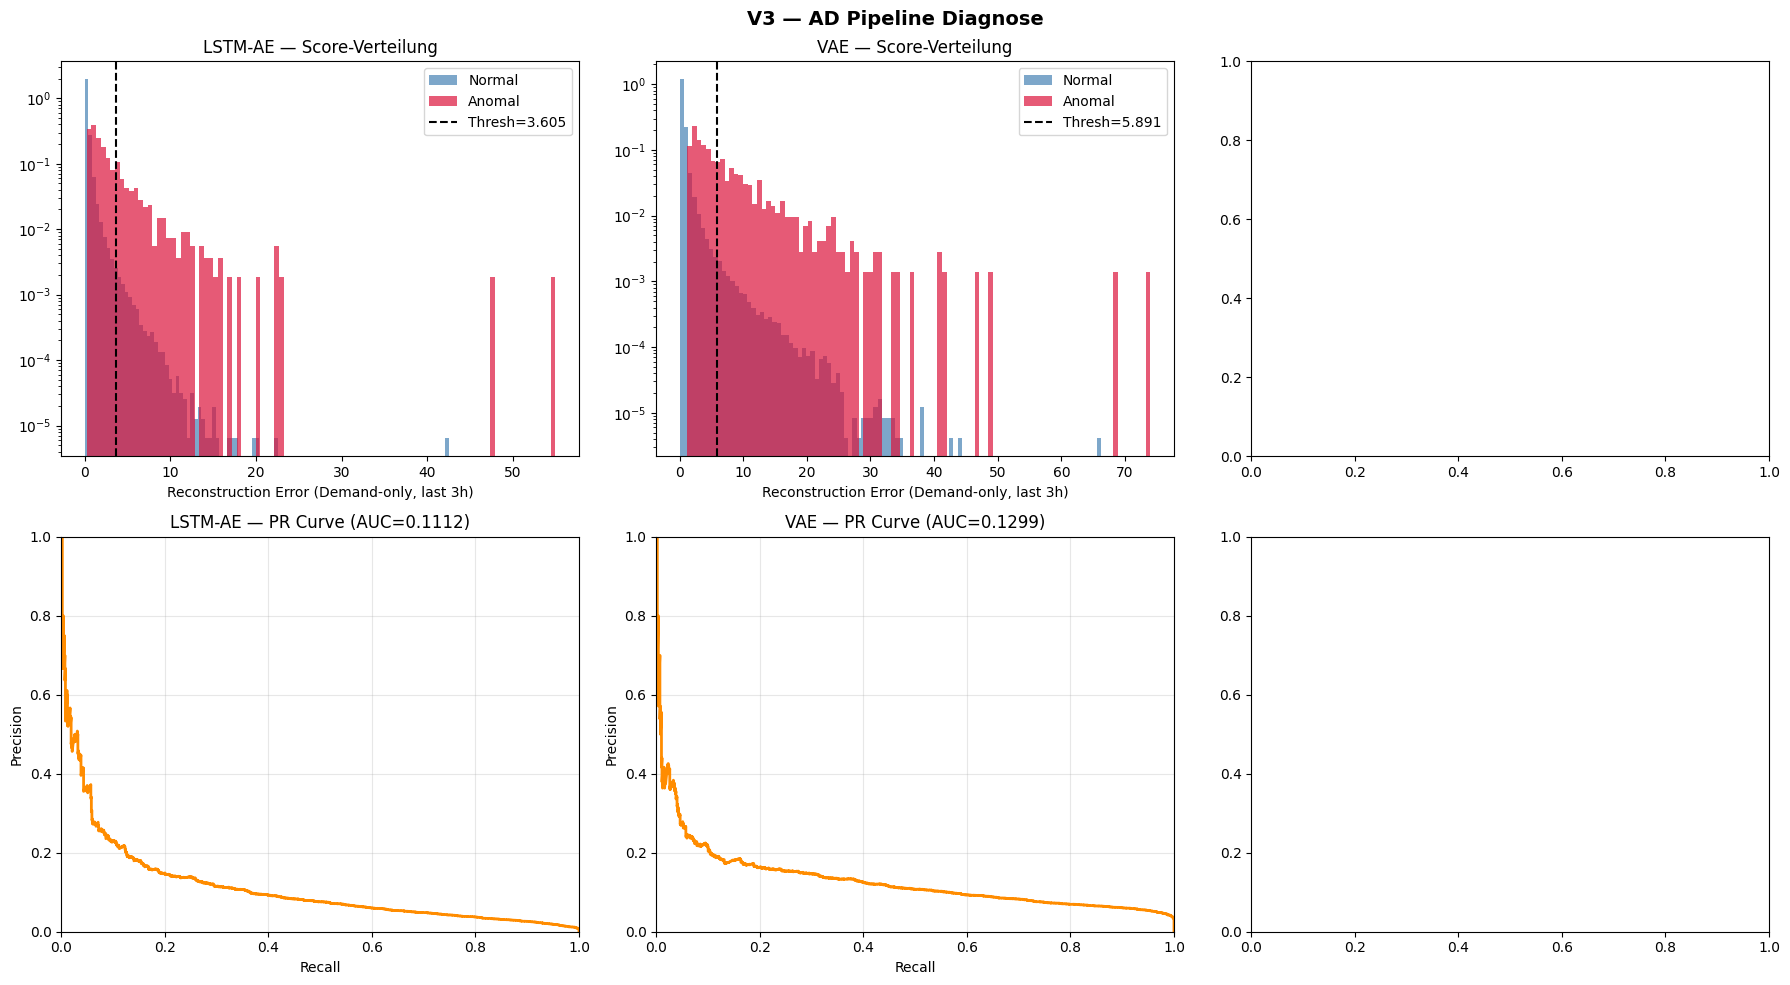

✅ Diagnose-Plots gespeichert.


In [19]:
# ══════════════════════════════════════════════════════════════
# 13 — Diagnose-Plots
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('V3 — AD Pipeline Diagnose', fontsize=14, fontweight='bold')

for idx, (results, name) in enumerate([
    #(results_vanilla, 'VanillaAE'),
    (results_lstm, 'LSTM-AE'),
    (results_vae, 'VAE')
]):
    scores = results['scores']
    binary = (y_test == 'anomal').astype(int)

    # Score-Verteilung
    ax = axes[0, idx]
    ax.hist(scores[binary == 0], bins=100, alpha=0.7, label='Normal', density=True, color='steelblue')
    ax.hist(scores[binary == 1], bins=100, alpha=0.7, label='Anomal', density=True, color='crimson')
    ax.axvline(results['threshold'], color='k', linestyle='--', label=f'Thresh={results["threshold"]:.3f}')
    ax.set_title(f'{name} — Score-Verteilung')
    ax.set_xlabel('Reconstruction Error (Demand-only, last 3h)')
    ax.legend()
    ax.set_yscale('log')

    # Precision-Recall Curve
    ax = axes[1, idx]
    prec, rec, _ = precision_recall_curve(binary, scores)
    ax.plot(rec, prec, color='darkorange', lw=2)
    ax.set_title(f'{name} — PR Curve (AUC={results["auc_pr"]:.4f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('✅ Diagnose-Plots gespeichert.')




In [ ]:
# ══════════════════════════════════════════════════════════════
# 14 — Modelle speichern
# ══════════════════════════════════════════════════════════════

save_dir = '/content/data/models'
os.makedirs(save_dir, exist_ok=True)

torch.save(vanilla_ae.state_dict(), f'{save_dir}/v3_vanilla_ae_mannheim.pth')
torch.save(lstm_ae.state_dict(),    f'{save_dir}/v3_lstm_ae_mannheim.pth')
torch.save(vae.state_dict(),        f'{save_dir}/v3_vae_mannheim.pth')

# Scaler & Config speichern (für Cross-City Transfer!)
import pickle
config = {
    'FEATURE_COLS': FEATURE_COLS,
    'DEMAND_FEATURE_INDICES': DEMAND_FEATURE_INDICES,
    'WINDOW_SIZE': WINDOW_SIZE,
    'LATENT_DIM': LATENT_DIM,
    'N_FEATURES': N_FEATURES,
    'SCORE_LAST_N_STEPS': SCORE_LAST_N_STEPS,
    'MIN_HIST_MEAN': MIN_HIST_MEAN,
    'MIN_ABSOLUTE': MIN_ABSOLUTE,
    'Z_ANOMALY_THRESHOLD': Z_ANOMALY_THRESHOLD,
    'thresholds': {
        'vanilla_ae': thresh_v,
        'lstm_ae': thresh_l,
        'vae': thresh_vae,
    },
    'results': {
        'vanilla_ae': {k: v for k, v in results_vanilla.items() if k != 'scores' and k != 'preds'},
        'lstm_ae':    {k: v for k, v in results_lstm.items() if k != 'scores' and k != 'preds'},
        'vae':        {k: v for k, v in results_vae.items() if k != 'scores' and k != 'preds'},
    }
}
with open(f'{save_dir}/v3_config.pkl', 'wb') as f:
    pickle.dump(config, f)

with open(f'{save_dir}/v3_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f'\n✅ Alles gespeichert in {save_dir}/')
print('   → Modelle, Scaler und Config bereit für Cross-City Transfer.')